In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
SEED = 42

df = pd.read_csv('db_pap3.csv')
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head()

Dimensiones: 10127 filas × 17 columnas


,clientnum,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
0,768805383,1,45,M,3,High School,Married,5833.333333333333,Blue,39,5,1,3,12691.0,777,1144,42
1,818770008,1,49,F,5,Graduate,Single,1666.6666666666667,Blue,44,6,1,2,8256.0,864,1291,33
2,713982108,1,51,M,3,Graduate,Married,8333.333333333334,Blue,36,4,1,0,3418.0,0,1887,20
3,769911858,1,40,F,4,High School,Unknown,1666.6666666666667,Blue,34,3,4,1,3313.0,2517,1171,20
4,709106358,1,40,M,3,Uneducated,Married,5833.333333333333,Blue,21,5,1,0,4716.0,0,816,28


## 1. Análisis Descriptivo y Agrupado

In [9]:
df.tail(5)

,clientnum,client_stayed,customer_age,gender,dependent_count,education_level,marital_status,income_category,card_category,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
10122,772366833,1,50,M,2,Graduate,Single,4166.666666666667,Blue,40,3,2,3,4003.0,1851,15476,117
10123,710638233,0,41,M,2,Unknown,Divorced,4166.666666666667,Blue,25,4,2,3,4277.0,2186,8764,69
10124,716506083,0,44,F,1,High School,Married,1666.6666666666667,Blue,36,5,3,4,5409.0,0,10291,60
10125,717406983,0,30,M,2,Graduate,Unknown,4166.666666666667,Blue,36,4,3,3,5281.0,0,8395,62
10126,714337233,0,43,F,2,Graduate,Married,1666.6666666666667,Silver,25,6,2,4,10388.0,1961,10294,61


In [2]:
info_df = pd.DataFrame({
    'dtype': df.dtypes,
    'n_unique': df.nunique(),
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2)
})
info_df

,dtype,n_unique,missing,missing_%
clientnum,int64,10127,0,0.0
client_stayed,int64,2,0,0.0
customer_age,int64,45,0,0.0
gender,str,2,0,0.0
dependent_count,int64,6,0,0.0
education_level,str,7,0,0.0
marital_status,str,4,0,0.0
income_category,str,6,0,0.0
card_category,str,4,0,0.0
months_on_book,int64,44,0,0.0


In [3]:
df.describe().round(2)

,clientnum,client_stayed,customer_age,dependent_count,months_on_book,total_relationship_count,months_inactive_12_mon,contacts_count_12_mon,credit_limit,total_revolving_bal,total_trans_amt,total_trans_ct
count,1.012700e+04,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,7.391776e+08,0.84,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,4404.09,64.86
std,3.690378e+07,0.37,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,3397.13,23.47
min,7.080821e+08,0.00,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,510.00,10.00
25%,7.130368e+08,1.00,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,2155.50,45.00
50%,7.179264e+08,1.00,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3899.00,67.00
75%,7.731435e+08,1.00,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,4741.00,81.00
max,8.283431e+08,1.00,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,18484.00,139.00


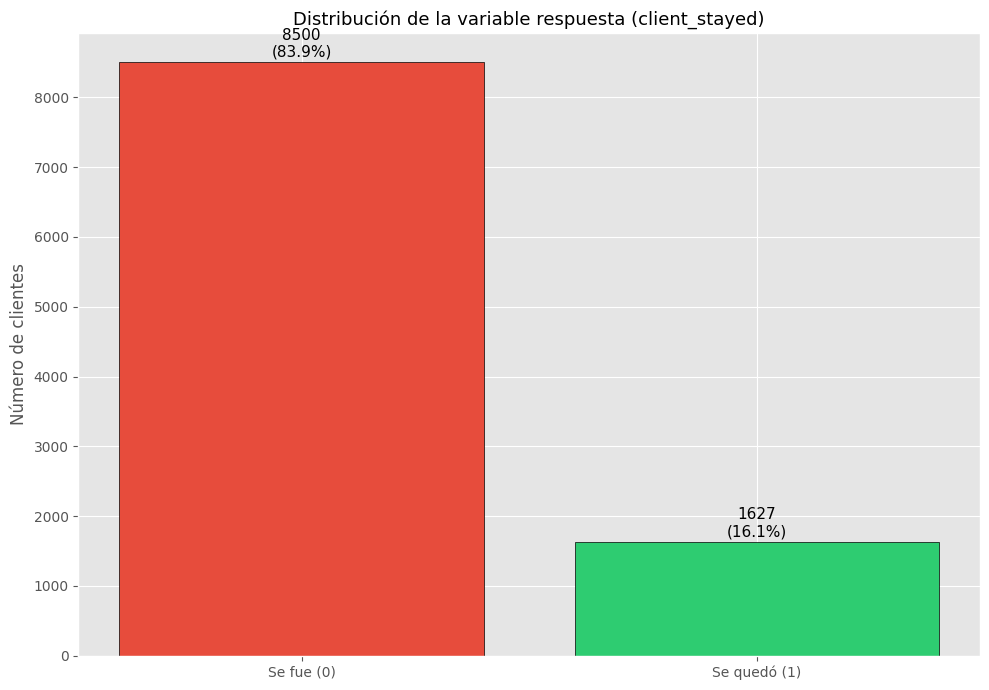

Ratio de churn: 16.1% abandona | 83.9% se queda


In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

counts = df['client_stayed'].value_counts()

bars = ax.bar(['Se fue (0)', 'Se quedó (1)'], counts.values, color=['#e74c3c','#2ecc71'], edgecolor='black')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
            f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Distribución de la variable respuesta (client_stayed)', fontsize=13)
ax.set_ylabel('Número de clientes')
plt.tight_layout()
plt.show()
print(f"Ratio de churn: {counts[0]/len(df)*100:.1f}% abandona | {counts[1]/len(df)*100:.1f}% se queda")

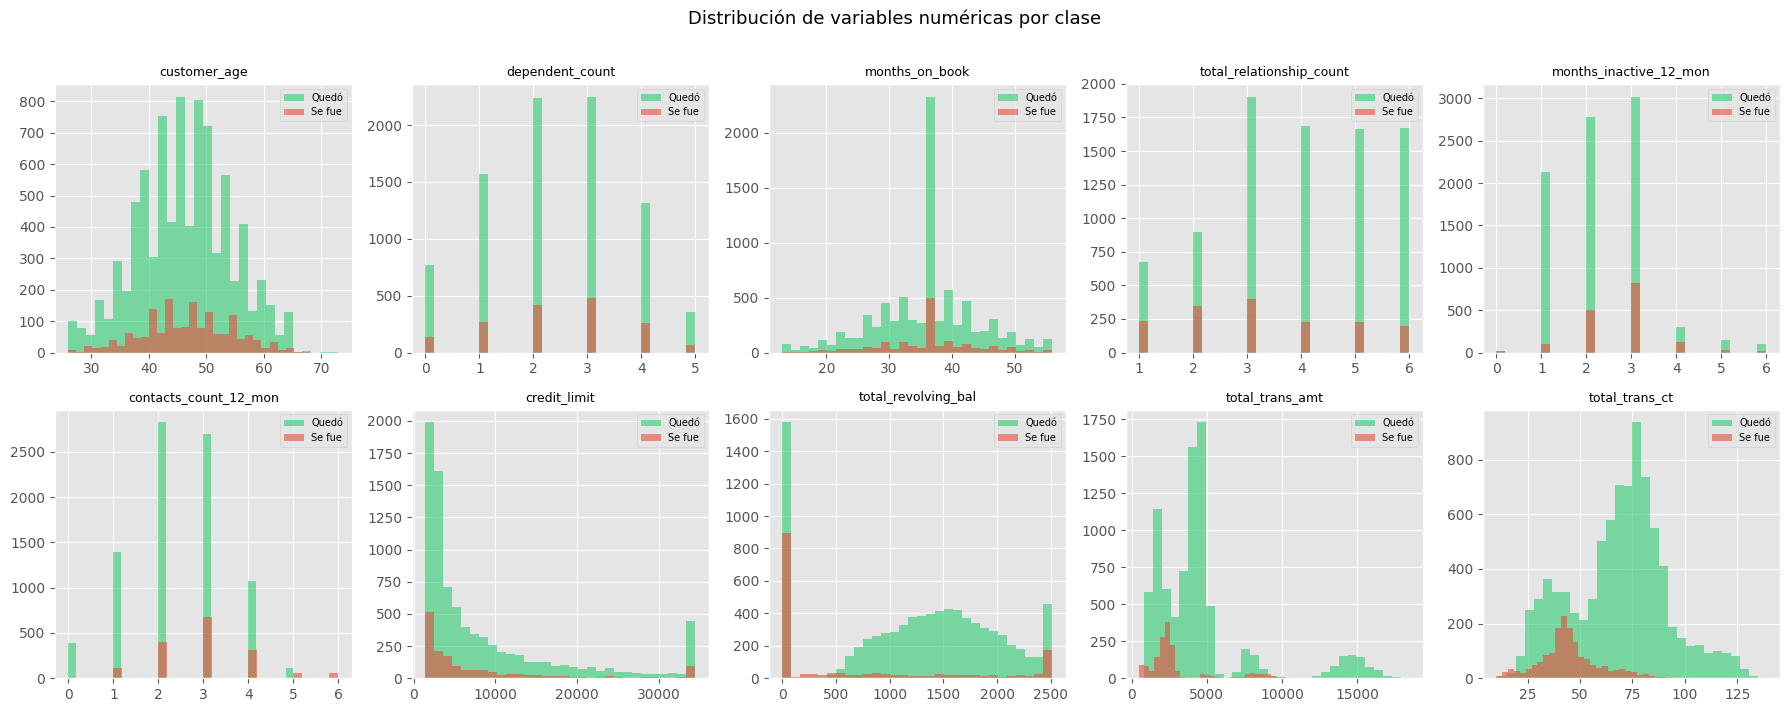

In [6]:
num_cols = ['customer_age','dependent_count','months_on_book','total_relationship_count',
            'months_inactive_12_mon','contacts_count_12_mon','credit_limit',
            'total_revolving_bal','total_trans_amt','total_trans_ct']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['client_stayed']==1][col], bins=30, alpha=0.6, color='#2ecc71', label='Quedó')
    axes[i].hist(df[df['client_stayed']==0][col], bins=30, alpha=0.6, color='#e74c3c', label='Se fue')
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)

plt.suptitle('Distribución de variables numéricas por clase', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

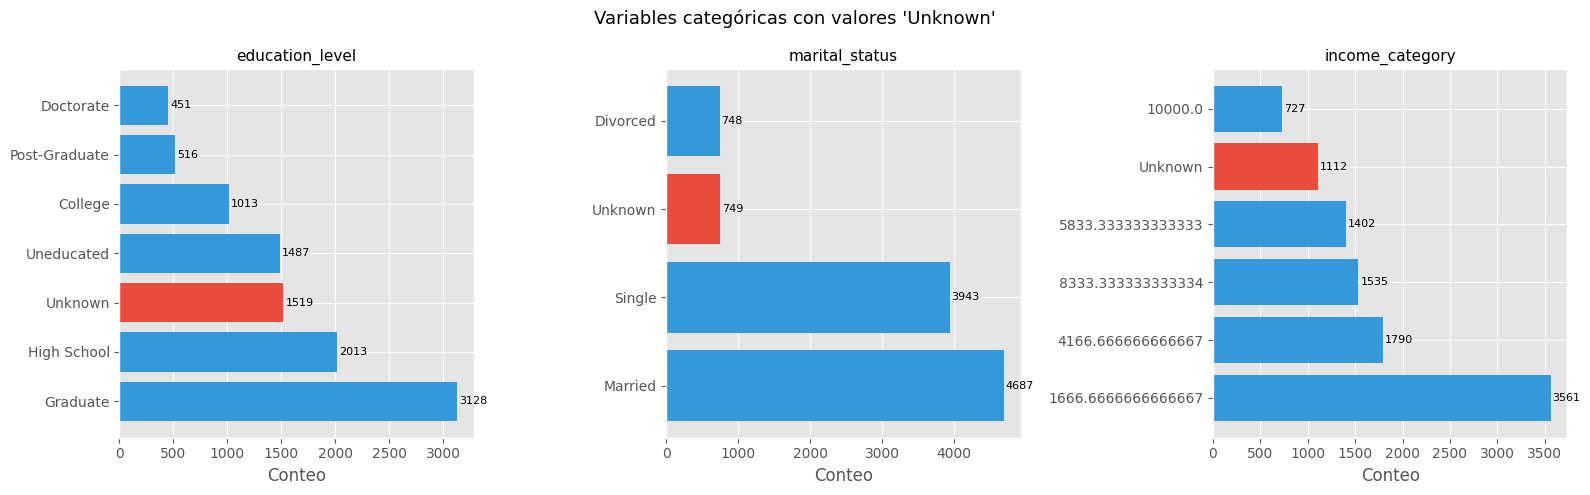

education_level: 15.0% Unknown
marital_status: 7.4% Unknown
income_category: 11.0% Unknown


In [7]:
cat_cols = ['education_level','marital_status','income_category','gender','card_category']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['education_level','marital_status','income_category']):
    vc = df[col].value_counts()
    colors = ['#e74c3c' if v == 'Unknown' else '#3498db' for v in vc.index]
    ax.barh(vc.index, vc.values, color=colors)
    ax.set_title(f'{col}', fontsize=11)
    ax.set_xlabel('Conteo')
    for j, v in enumerate(vc.values):
        ax.text(v + 20, j, str(v), va='center', fontsize=8)

plt.suptitle("Variables categóricas con valores 'Unknown'", fontsize=13)
plt.tight_layout()
plt.show()

# Porcentajes Unknown
for col in ['education_level','marital_status','income_category']:
    pct = (df[col] == 'Unknown').mean() * 100
    print(f"{col}: {pct:.1f}% Unknown")

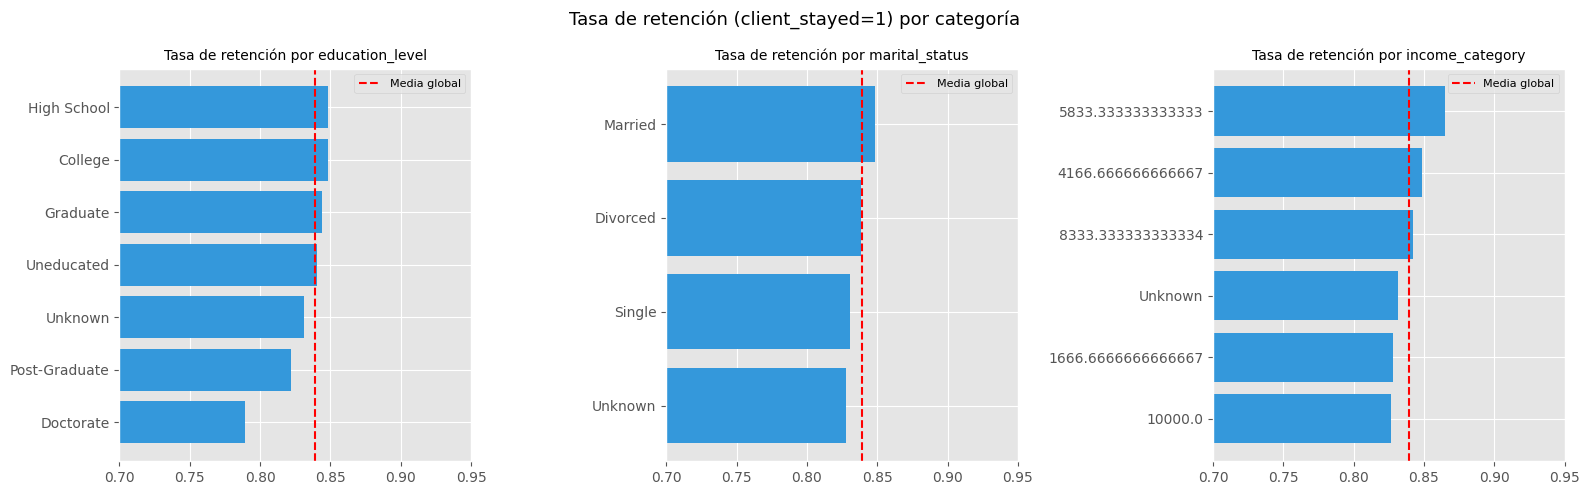

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['education_level','marital_status','income_category']):
    retention = df.groupby(col)['client_stayed'].mean().sort_values()
    ax.barh(retention.index, retention.values, color='#3498db')
    ax.axvline(df['client_stayed'].mean(), color='red', linestyle='--', label='Media global')
    ax.set_title(f'Tasa de retención por {col}', fontsize=10)
    ax.set_xlim(0.7, 0.95)
    ax.legend(fontsize=8)

plt.suptitle("Tasa de retención (client_stayed=1) por categoría", fontsize=13)
plt.tight_layout()
plt.show()

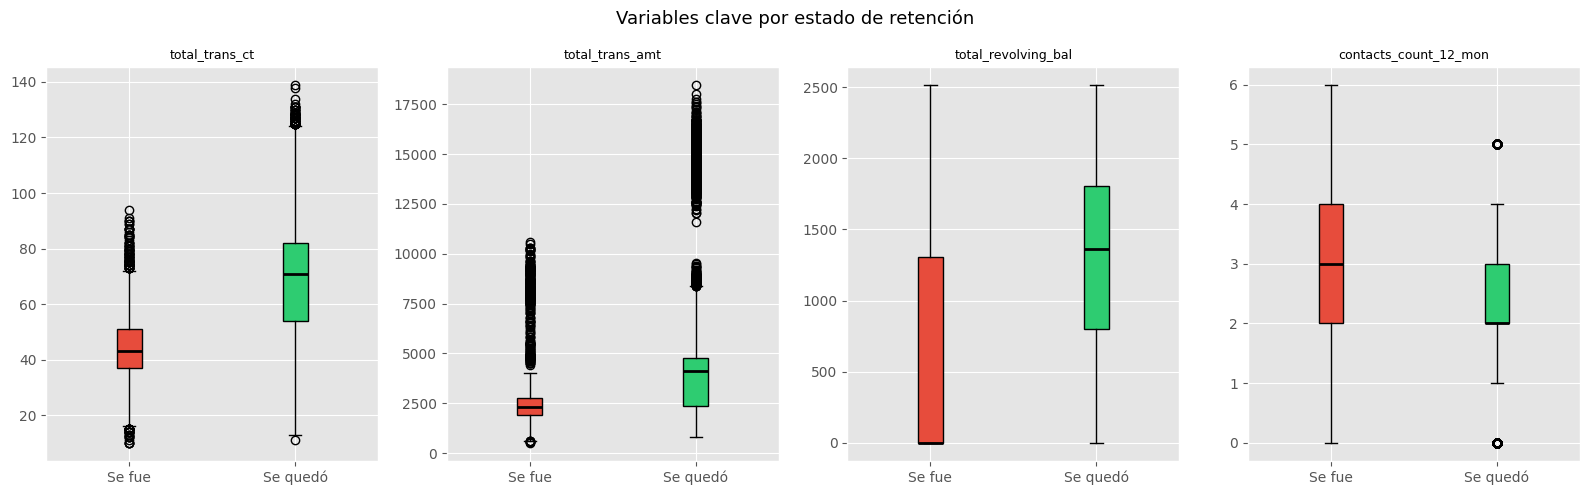

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
key_vars = ['total_trans_ct','total_trans_amt','total_revolving_bal','contacts_count_12_mon']

for ax, col in zip(axes, key_vars):
    data = [df[df['client_stayed']==0][col], df[df['client_stayed']==1][col]]
    bp = ax.boxplot(data, patch_artist=True,
                    boxprops=dict(facecolor='#e74c3c'),
                    medianprops=dict(color='black', linewidth=2))
    bp['boxes'][1].set_facecolor('#2ecc71')
    ax.set_xticklabels(['Se fue', 'Se quedó'])
    ax.set_title(col, fontsize=9)

plt.suptitle("Variables clave por estado de retención", fontsize=13)
plt.tight_layout()
plt.show()

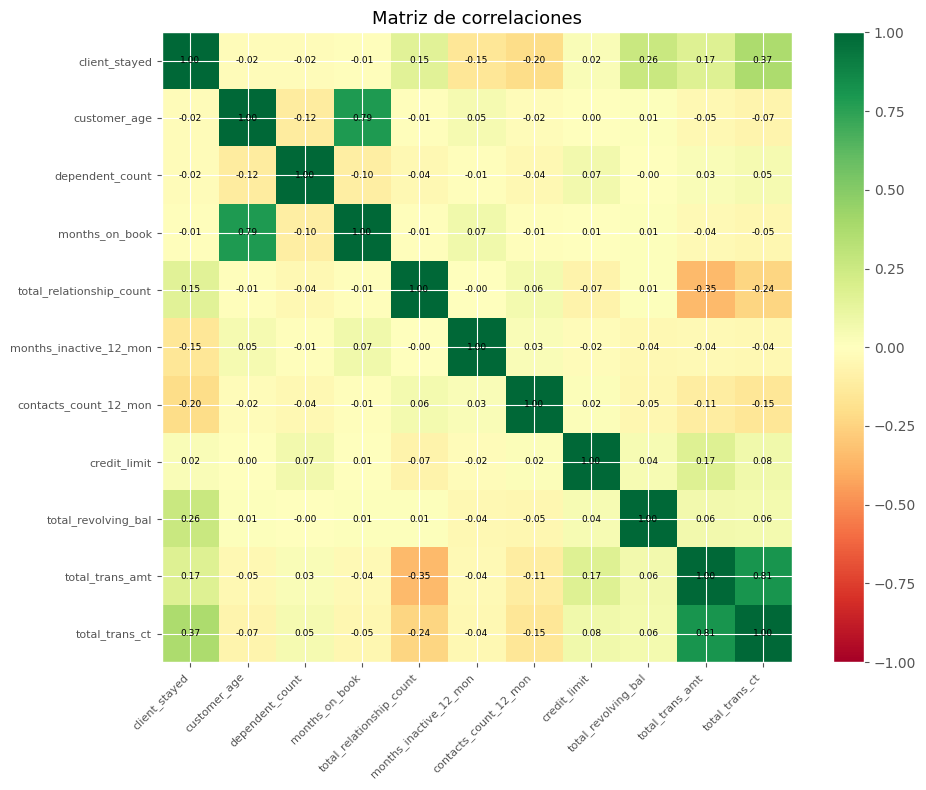

Correlaciones con client_stayed:
contacts_count_12_mon      -0.204
months_inactive_12_mon     -0.152
dependent_count            -0.019
customer_age               -0.018
months_on_book             -0.014
credit_limit                0.024
total_relationship_count    0.150
total_trans_amt             0.169
total_revolving_bal         0.263
total_trans_ct              0.371
Name: client_stayed, dtype: float64


In [11]:
numeric_df = df.select_dtypes(include='number').drop('clientnum', axis=1)
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=6.5)

ax.set_title('Matriz de correlaciones', fontsize=13)
plt.tight_layout()
plt.show()

print("Correlaciones con client_stayed:")
print(corr['client_stayed'].drop('client_stayed').sort_values().round(3))

## 2. Preprocesamiento

In [13]:
df_clean = df.copy()

# Mapear income_category a etiquetas legibles
income_map = {
    '1666.6666666666667': '<$20K',
    '4166.666666666667': '$40K-$60K',
    '5833.333333333333': '$60K-$80K',
    '8333.333333333334': '$80K-$120K',
    '10000.0': '$120K+',
    'Unknown': 'Unknown'
}
df_clean['income_category'] = df_clean['income_category'].map(income_map)
print("Categorías de income_category corregidas:")
print(df_clean['income_category'].value_counts())

Categorías de income_category corregidas:
income_category
<$20K         3561
$40K-$60K     1790
$80K-$120K    1535
$60K-$80K     1402
Unknown       1112
$120K+         727
Name: count, dtype: int64


In [14]:
# Imputar 'Unknown' con la moda condicional al target
cols_unknown = ['education_level', 'marital_status', 'income_category']

for col in cols_unknown:
    mode_by_group = df_clean[df_clean[col] != 'Unknown'].groupby('client_stayed')[col].agg(
        lambda x: x.mode()[0]
    )
    def impute(row):
        if row[col] == 'Unknown':
            return mode_by_group[row['client_stayed']]
        return row[col]
    df_clean[col] = df_clean.apply(impute, axis=1)
    print(f"{col} - Unknown restantes: {(df_clean[col] == 'Unknown').sum()}")

education_level - Unknown restantes: 0
marital_status - Unknown restantes: 0
income_category - Unknown restantes: 0


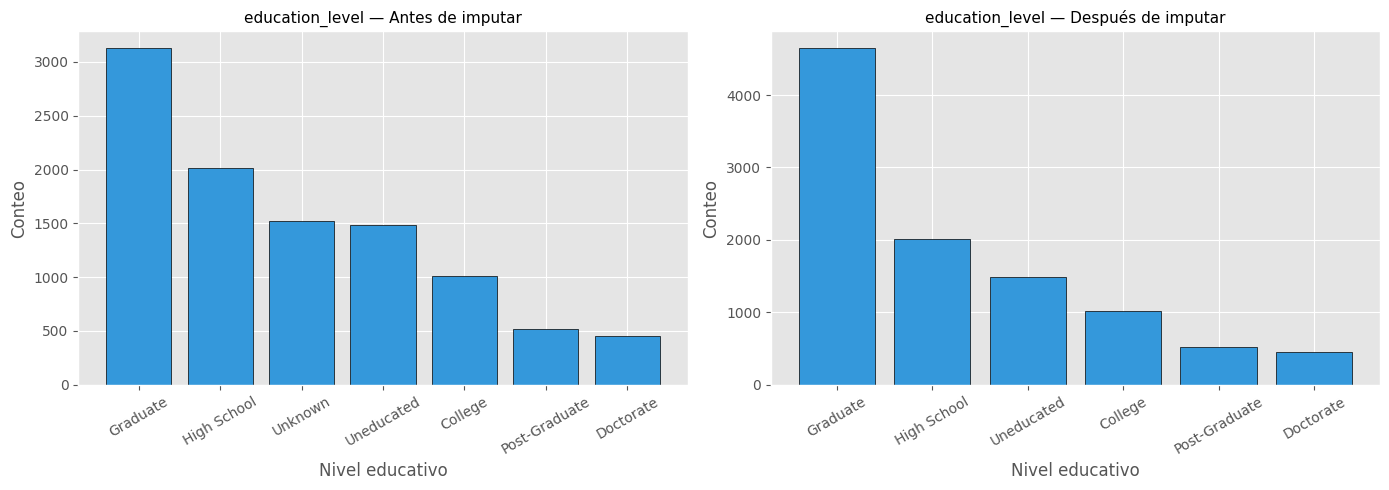

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (data, title) in zip(axes, [(df, 'Antes de imputar'), (df_clean, 'Después de imputar')]):
    vc = data['education_level'].value_counts()
    ax.bar(vc.index, vc.values, color='#3498db', edgecolor='black')
    ax.set_title(f'education_level — {title}', fontsize=11)
    ax.set_xlabel('Nivel educativo')
    ax.set_ylabel('Conteo')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [16]:
edu_order = {'Uneducated':0, 'High School':1, 'College':2, 'Graduate':3, 'Post-Graduate':4, 'Doctorate':5, 'Unknown':np.nan}
df_corr_antes = df.copy()
df_corr_antes['edu_code'] = df_corr_antes['education_level'].map(edu_order)
df_corr_despues = df_clean.copy()
df_corr_despues['edu_code'] = df_corr_despues['education_level'].map(edu_order)

print("Impacto de la imputación en education_level")
print(f"Correlación con target ANTES:  {df_corr_antes['edu_code'].corr(df['client_stayed']):.4f}")
print(f"Correlación con target DESPUÉS:{df_corr_despues['edu_code'].corr(df_clean['client_stayed']):.4f}")
print()
print(f"Moda ANTES:   {df['education_level'][df['education_level']!='Unknown'].mode()[0]}")
print(f"Moda DESPUÉS: {df_clean['education_level'].mode()[0]}")

Impacto de la imputación en education_level
Correlación con target ANTES:  -0.0207
Correlación con target DESPUÉS:-0.0207

Moda ANTES:   Graduate
Moda DESPUÉS: Graduate


In [17]:
from sklearn.preprocessing import OrdinalEncoder

df_proc = df_clean.copy()
df_proc.drop('clientnum', axis=1, inplace=True)

# Ordinal: education_level
edu_cats = ['Uneducated','High School','College','Graduate','Post-Graduate','Doctorate']
df_proc['education_level_ord'] = df_proc['education_level'].apply(
    lambda x: edu_cats.index(x) if x in edu_cats else -1
)

# Ordinal: income_category
inc_cats = ['<$20K','$40K-$60K','$60K-$80K','$80K-$120K','$120K+']
df_proc['income_category_ord'] = df_proc['income_category'].apply(
    lambda x: inc_cats.index(x) if x in inc_cats else -1
)

# One-hot: gender, marital_status, card_category
df_proc = pd.get_dummies(df_proc, columns=['gender','marital_status','card_category'], drop_first=True)
df_proc.drop(['education_level','income_category'], axis=1, inplace=True)

print(f"Shape después del encoding: {df_proc.shape}")
print(df_proc.columns.tolist())


Shape después del encoding: (10127, 19)
['client_stayed', 'customer_age', 'dependent_count', 'months_on_book', 'total_relationship_count', 'months_inactive_12_mon', 'contacts_count_12_mon', 'credit_limit', 'total_revolving_bal', 'total_trans_amt', 'total_trans_ct', 'education_level_ord', 'income_category_ord', 'gender_M', 'marital_status_Married', 'marital_status_Single', 'card_category_Gold', 'card_category_Platinum', 'card_category_Silver']


## 3. Ingeniería de Características (Feature Engineering)

In [18]:
df_fe = df_proc.copy()


df_fe['utilization_rate'] = df_fe['total_revolving_bal'] / (df_fe['credit_limit'] + 1)

print("Variable 1 creada: utilization_rate")
print(df_fe.groupby('client_stayed')['utilization_rate'].mean().round(4))


Variable 1 creada: utilization_rate
client_stayed
0    0.1624
1    0.2963
Name: utilization_rate, dtype: float64


In [19]:
df_fe['avg_trans_value'] = df_fe['total_trans_amt'] / (df_fe['total_trans_ct'] + 1)

print("Variable 2 creada: avg_trans_value")
print(df_fe.groupby('client_stayed')['avg_trans_value'].mean().round(2))

Variable 2 creada: avg_trans_value
client_stayed
0    62.14
1    61.47
Name: avg_trans_value, dtype: float64


In [20]:
df_fe['inactivity_ratio'] = df_fe['months_inactive_12_mon'] / 12.0

print("Variable 3 creada: inactivity_ratio")
print(df_fe.groupby('client_stayed')['inactivity_ratio'].mean().round(4))


Variable 3 creada: inactivity_ratio
client_stayed
0    0.2244
1    0.1895
Name: inactivity_ratio, dtype: float64


In [21]:
df_fe['products_per_year'] = df_fe['total_relationship_count'] / (df_fe['months_on_book'] / 12 + 0.01)

print("Variable 4 creada: products_per_year")
print(df_fe.groupby('client_stayed')['products_per_year'].mean().round(4))


Variable 4 creada: products_per_year
client_stayed
0    1.1467
1    1.3902
Name: products_per_year, dtype: float64


In [22]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

df_fe['engagement_score'] = (
    minmax(df_fe['total_trans_ct']) +
    minmax(df_fe['total_relationship_count']) +
    minmax(df_fe['total_revolving_bal'])
) / 3

print("Variable 5 creada: engagement_score")
print(df_fe.groupby('client_stayed')['engagement_score'].mean().round(4))

Variable 5 creada: engagement_score
client_stayed
0    0.3313
1    0.5123
Name: engagement_score, dtype: float64


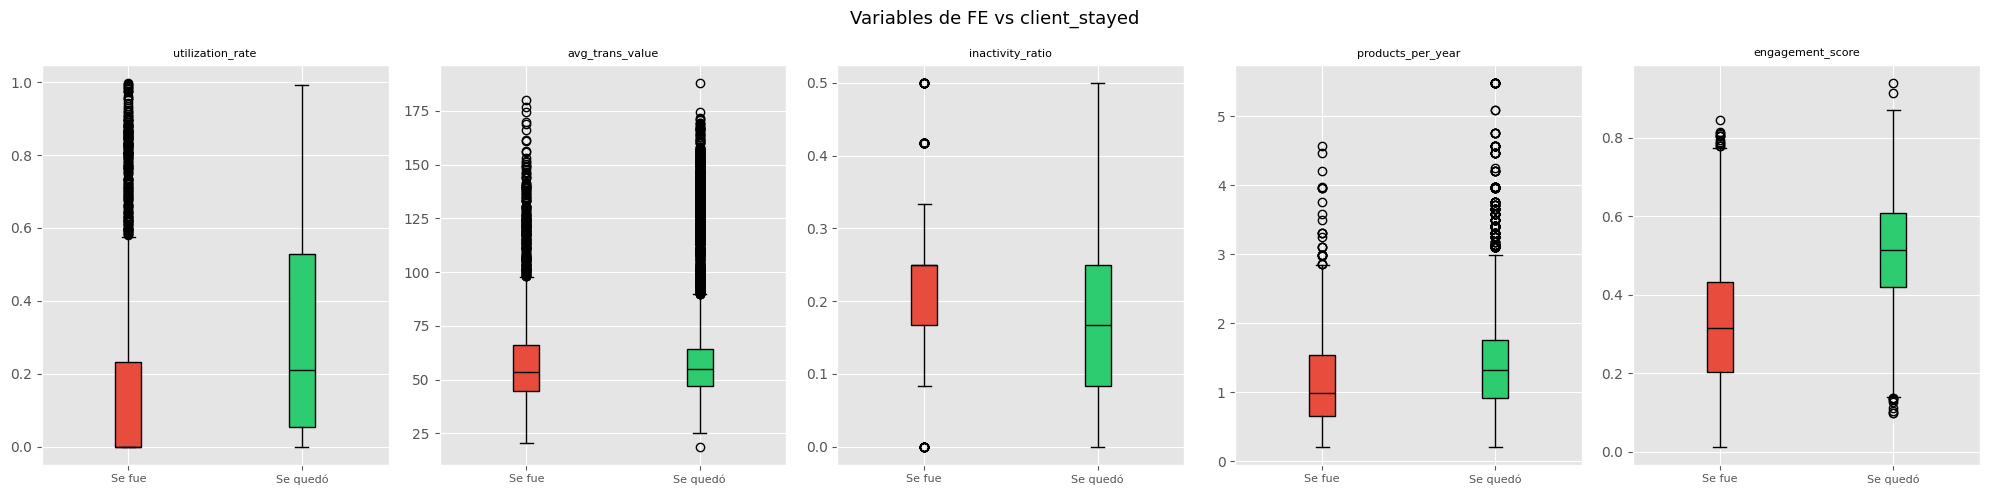

In [23]:
new_vars = ['utilization_rate','avg_trans_value','inactivity_ratio','products_per_year','engagement_score']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, col in zip(axes, new_vars):
    data = [df_fe[df_fe['client_stayed']==0][col], df_fe[df_fe['client_stayed']==1][col]]
    bp = ax.boxplot(data, patch_artist=True)
    bp['boxes'][0].set_facecolor('#e74c3c')
    bp['boxes'][1].set_facecolor('#2ecc71')
    bp['medians'][0].set_color('black')
    bp['medians'][1].set_color('black')
    ax.set_xticklabels(['Se fue','Se quedó'], fontsize=8)
    ax.set_title(col, fontsize=8)

plt.suptitle("Variables de FE vs client_stayed", fontsize=13)
plt.tight_layout()
plt.show()

In [24]:
print("Correlaciones de variables de FE con client_stayed:")
for col in new_vars:
    r = df_fe[col].corr(df_fe['client_stayed'])
    print(f"  {col:25s}: {r:.4f}")

Correlaciones de variables de FE con client_stayed:
  utilization_rate         : 0.1784
  avg_trans_value          : -0.0094
  inactivity_ratio         : -0.1524
  products_per_year        : 0.1273
  engagement_score         : 0.4284


## 4. Selección de Variables

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_fe.drop('client_stayed', axis=1)
y = df_fe['client_stayed']

# Estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Eliminar variables con alta correlación entre predictores (|r| > 0.85)
corr_matrix = X_scaled_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
print(f"Variables eliminadas por alta correlación entre predictores: {to_drop_corr}")

X_filtered = X_scaled_df.drop(columns=to_drop_corr)

Variables eliminadas por alta correlación entre predictores: ['marital_status_Single', 'avg_trans_value', 'inactivity_ratio']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=SEED, stratify=y)

lr = LogisticRegression(max_iter=1000, random_state=SEED)
lr.fit(X_train, y_train)

coef_df = pd.DataFrame({
    'variable': X_filtered.columns,
    'coef_abs': np.abs(lr.coef_[0]),
    'coef': lr.coef_[0]
}).sort_values('coef_abs', ascending=False)

print("Importancia de variables (|coeficiente| de regresión logística):")
print(coef_df.head(15).to_string(index=False))

Importancia de variables (|coeficiente| de regresión logística):
              variable  coef_abs      coef
        total_trans_ct  2.347501  2.347501
       total_trans_amt  1.448769 -1.448769
      engagement_score  0.946820  0.946820
 contacts_count_12_mon  0.600383 -0.600383
              gender_M  0.567256  0.567256
months_inactive_12_mon  0.521291 -0.521291
   income_category_ord  0.326809 -0.326809
marital_status_Married  0.261193  0.261193
     products_per_year  0.194500  0.194500
       dependent_count  0.156188 -0.156188
          credit_limit  0.134061  0.134061
   total_revolving_bal  0.117603  0.117603
        months_on_book  0.112741  0.112741
  card_category_Silver  0.095448 -0.095448
    card_category_Gold  0.089467 -0.089467


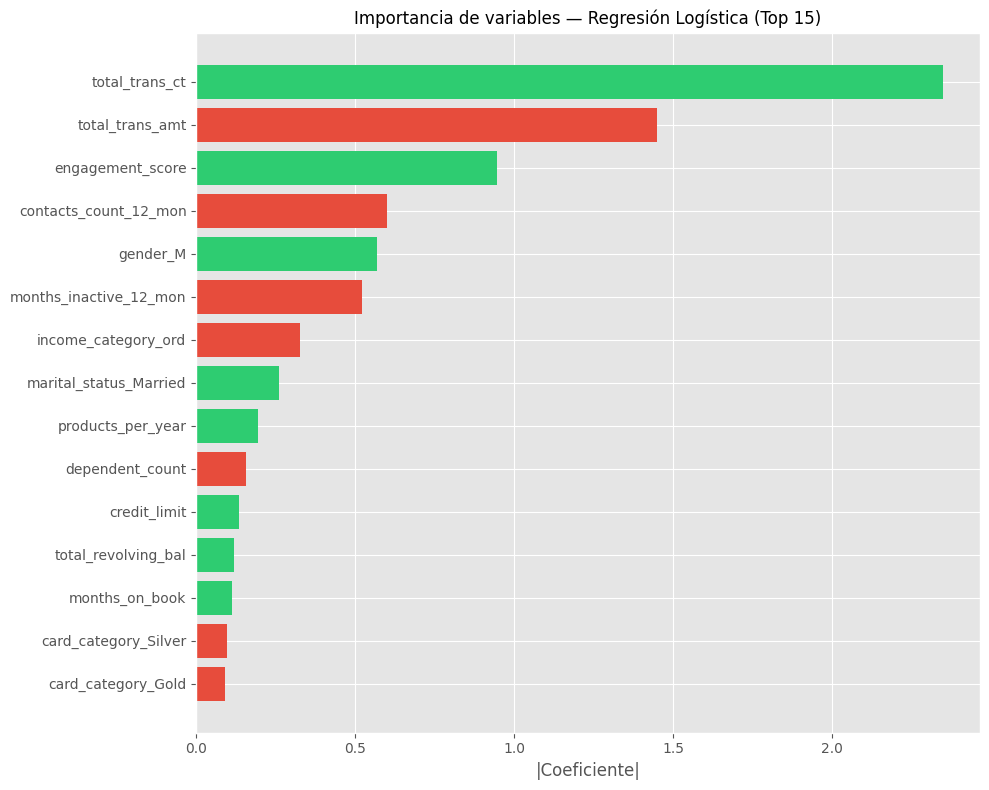

In [27]:
fig, ax = plt.subplots(figsize=(10, 8))
top15 = coef_df.head(15)
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top15['coef']]
ax.barh(top15['variable'][::-1], top15['coef_abs'][::-1], color=colors[::-1])
ax.set_xlabel('|Coeficiente|')
ax.set_title('Importancia de variables — Regresión Logística (Top 15)', fontsize=12)
plt.tight_layout()
plt.show()

In [28]:
THRESHOLD = coef_df.iloc[9]['coef_abs']  # top 10
selected_vars = coef_df[coef_df['coef_abs'] >= THRESHOLD]['variable'].tolist()
print(f"Variables seleccionadas ({len(selected_vars)}):", selected_vars)

# ¿Aparecen las variables de FE?
fe_in_selection = [v for v in new_vars if v in selected_vars]
print(f"\nVariables de FE seleccionadas: {fe_in_selection}")

Variables seleccionadas (10): ['total_trans_ct', 'total_trans_amt', 'engagement_score', 'contacts_count_12_mon', 'gender_M', 'months_inactive_12_mon', 'income_category_ord', 'marital_status_Married', 'products_per_year', 'dependent_count']

Variables de FE seleccionadas: ['products_per_year', 'engagement_score']


In [29]:
from sklearn.metrics import roc_auc_score

X_train_all, X_test_all, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=SEED, stratify=y)

lr_all = LogisticRegression(max_iter=1000, random_state=SEED)
lr_all.fit(X_train_all, y_train)
auc_all = roc_auc_score(y_test, lr_all.predict_proba(X_test_all)[:,1])

X_sel = X_filtered[selected_vars]
X_train_sel, X_test_sel = X_train_all[selected_vars], X_test_all[selected_vars]

lr_sel = LogisticRegression(max_iter=1000, random_state=SEED)
lr_sel.fit(X_train_sel, y_train)
auc_sel = roc_auc_score(y_test, lr_sel.predict_proba(X_test_sel)[:,1])

print(f"AUC — todas las variables ({X_filtered.shape[1]}): {auc_all:.4f}")
print(f"AUC — variables seleccionadas ({len(selected_vars)}):    {auc_sel:.4f}")
print(f"\nLas variables seleccionadas mantienen el mismo AUC con menos variables - selección válida.")

AUC — todas las variables (20): 0.9114
AUC — variables seleccionadas (10):    0.9101

Las variables seleccionadas mantienen el mismo AUC con menos variables - selección válida.


## 5. Análisis de Componentes Principales (PCA)

In [30]:
# PCA manual usando numpy
X_pca_input = X_filtered.values.copy()  # ya está estandarizado

# Paso 1: Centrar los datos (media ya es ~0 por StandardScaler, pero lo hacemos explícito)
X_centered = X_pca_input - X_pca_input.mean(axis=0)

# Paso 2: Matriz de covarianza
cov_matrix = np.cov(X_centered, rowvar=False)

# Paso 3: Eigenvalores y eigenvectores
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Paso 4: Ordenar de mayor a menor
sorted_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# Paso 5: Varianza explicada
total_var = eigenvalues.sum()
explained_var = eigenvalues / total_var
cumulative_var = np.cumsum(explained_var)

print("Varianza explicada por componente (primeras 15):")
for i in range(15):
    print(f"  PC{i+1:02d}: {explained_var[i]*100:.2f}%  | Acumulada: {cumulative_var[i]*100:.2f}%")

Varianza explicada por componente (primeras 15):
  PC01: 14.54%  | Acumulada: 14.54%
  PC02: 12.07%  | Acumulada: 26.61%
  PC03: 11.31%  | Acumulada: 37.92%
  PC04: 9.82%  | Acumulada: 47.74%
  PC05: 6.34%  | Acumulada: 54.09%
  PC06: 5.22%  | Acumulada: 59.30%
  PC07: 5.15%  | Acumulada: 64.45%
  PC08: 5.11%  | Acumulada: 69.56%
  PC09: 5.07%  | Acumulada: 74.63%
  PC10: 4.91%  | Acumulada: 79.54%
  PC11: 4.88%  | Acumulada: 84.43%
  PC12: 4.70%  | Acumulada: 89.13%
  PC13: 4.50%  | Acumulada: 93.63%
  PC14: 2.12%  | Acumulada: 95.75%
  PC15: 1.21%  | Acumulada: 96.96%


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (20,) and arg 1 with shape (19,).

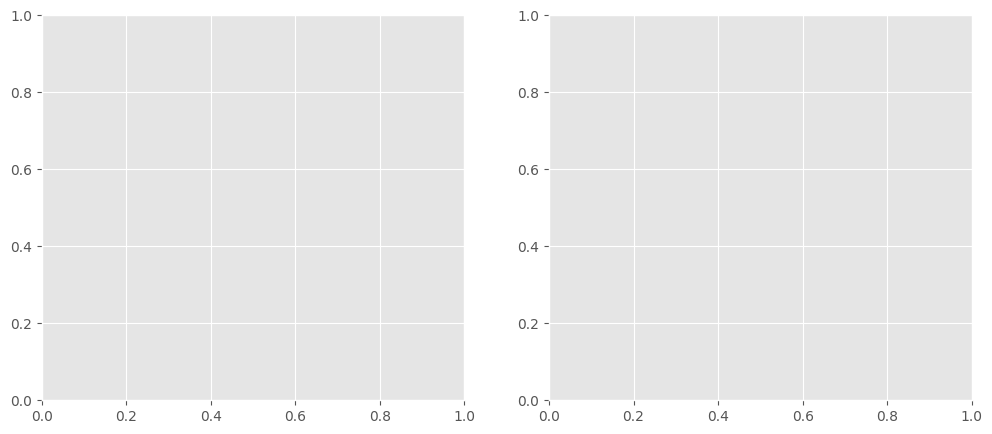

In [31]:
# Gráfica del codo (scree plot)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

n_comp = len(eigenvalues)
ax1.bar(range(1, min(20, n_comp)+1), explained_var[:19]*100, color='#3498db')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza explicada (%)')
ax1.set_title('Scree Plot — Varianza por componente')

ax2.plot(range(1, n_comp+1), cumulative_var*100, marker='o', markersize=3, color='#e74c3c')
ax2.axhline(80, color='gray', linestyle='--', label='80%')
ax2.axhline(90, color='black', linestyle='--', label='90%')
ax2.set_xlabel('Número de componentes')
ax2.set_ylabel('Varianza acumulada (%)')
ax2.set_title('Varianza Acumulada Explicada')
ax2.legend()
ax2.set_xlim(0, 20)

plt.tight_layout()
plt.show()

# ¿Cuántos componentes para 80% y 90%?
n_80 = np.argmax(cumulative_var >= 0.80) + 1
n_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"Componentes para 80% de varianza: {n_80}")
print(f"Componentes para 90% de varianza: {n_90}")
